#CREDIT RISK ANALYTICS-LOAN DEFAULT PREDICTION

##Business Understanding

Banks such as KCB Bank face significant credit risk when issuing loans because some borrowers may fail to repay their obligations. Poor lending decisions can lead to increased loan defaults, reduced profitability, and higher financial losses.

To minimize these risks, financial institutions use data-driven credit risk models to assess applicants before approving loans. By analyzing customer demographics, financial history, and loan-related characteristics, banks can identify high-risk borrowers and make better lending decisions.

This project aims to develop a predictive credit risk model using the Home Credit dataset to support smarter lending decisions and reduce default risk.

##Problem Statement

Loan defaults pose a major challenge for financial institutions because they directly impact profitability and financial stability. Traditional credit assessment methods may not fully capture complex patterns associated with borrower default behavior.

The challenge is to build a predictive model that can accurately identify customers who are likely to default on their loans, enabling banks to improve risk management and make more informed lending decisions.

##Objectives



1.   To develop a machine learning model that predicts the likelihood of loan default and supports data-driven credit risk assessment
2.   Perform exploratory data analysis (EDA) to understand borrower characteristics and default patterns.


1.  Identify the key factors that influence loan default risk.
2.   Build and compare classification models for predicting loan default.


1.  Evaluate model performance using appropriate classification metrics.
2.   Determine the most important features influencing default predictions.


1.  Generate insights that can help improve lending decisions and risk management.









##Key questions the analysis should answer
Key Questions the Analysis Should Answer by the end of the project:



1.   What characteristics are common among customers who default on loans?
2.  Which customer attributes are most strongly associated with default risk?

1.   How do income, employment status, and credit history affect loan repayment behavior?
2.   Which variables are the strongest predictors of loan default?

1.   Can machine learning accurately predict whether a customer will default?
2.   Which classification model performs best for credit risk prediction?

1.   How can the model help reduce lending risk and improve loan approval decisions?










##

##Data Understanding

In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading dataset
df=pd.read_csv('/content/Loan_default_messy.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,NaN,50587,520.0,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432.0,124440,458.0,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208.0,129188,451.0,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713.0,44799,743.0,0,3,7.07,24,0.23,High School,NaN,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437.0,9139,633.0,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [3]:
#Checking information on the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208168 entries, 0 to 208167
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          208168 non-null  object 
 1   Age             208168 non-null  int64  
 2   Income          201891 non-null  float64
 3   LoanAmount      208168 non-null  int64  
 4   CreditScore     203976 non-null  float64
 5   MonthsEmployed  208168 non-null  int64  
 6   NumCreditLines  208168 non-null  int64  
 7   InterestRate    208168 non-null  float64
 8   LoanTerm        208168 non-null  int64  
 9   DTIRatio        208168 non-null  float64
 10  Education       208167 non-null  object 
 11  EmploymentType  203979 non-null  object 
 12  MaritalStatus   208167 non-null  object 
 13  HasMortgage     208167 non-null  object 
 14  HasDependents   208167 non-null  object 
 15  LoanPurpose     208167 non-null  object 
 16  HasCoSigner     208167 non-null  object 
 17  Default   

This shows that the dataset contains 18 columns

In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,208168.000000,2.018910e+05,2.081680e+05,203976.000000,208168.000000,208168.000000,208168.000000,208168.000000,208168.000000,208167.000000
mean,43.467560,8.823343e+04,1.323642e+05,574.388389,59.550983,2.500428,13.488965,36.051305,0.500075,0.116253
std,14.984368,7.576245e+04,9.280571e+04,158.845789,34.614071,1.116798,6.631936,16.969466,0.230778,0.320529
min,18.000000,1.500000e+04,5.000000e+03,300.000000,0.000000,1.000000,2.000000,12.000000,0.000000,0.000000
25%,31.000000,4.910750e+04,6.654100e+04,437.000000,30.000000,2.000000,7.780000,24.000000,0.300000,0.000000
50%,43.000000,8.321300e+04,1.283305e+05,574.000000,60.000000,2.000000,13.450000,36.000000,0.500000,0.000000
75%,56.000000,1.172370e+05,1.902172e+05,712.000000,89.000000,3.000000,19.240000,48.000000,0.700000,0.000000
max,69.000000,1.199856e+06,1.247495e+06,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


This shows the statistical data that I am working with on this dataset ie.mean,standard deviation etc.

In [5]:
#Checking columns and rows
df.shape

(208168, 18)

This shows that the dataset contains 257900 rows and 18 columns.

In [6]:
df.nunique()

,0
LoanID,208168
Age,52
Income,106339
LoanAmount,141346
CreditScore,550
MonthsEmployed,120
NumCreditLines,4
InterestRate,2301
LoanTerm,5
DTIRatio,82


Checking whether there are unique values in the dataset

##Data Cleaning

###Handling missing values.

In [7]:
#Checking for missing values
df.isna().sum()


,0
LoanID,0
Age,0
Income,6277
LoanAmount,0
CreditScore,4192
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


There are missing values from three columns mainly:Income,creditscore and employment type.The next step is to figure out the best way to handle the missing values.

In [8]:
#Checking the data type of the columns
df.dtypes

,0
LoanID,object
Age,int64
Income,float64
LoanAmount,int64
CreditScore,float64
MonthsEmployed,int64
NumCreditLines,int64
InterestRate,float64
LoanTerm,int64
DTIRatio,float64


In [9]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,NaN,50587,520.0,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432.0,124440,458.0,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208.0,129188,451.0,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713.0,44799,743.0,0,3,7.07,24,0.23,High School,NaN,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437.0,9139,633.0,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [10]:
#Checking the percentage of the missing values in the columns with missing values
missing_percent=df.isna().sum()/ len(df) * 100
missing_percent

,0
LoanID,0.000000
Age,0.000000
Income,3.015353
LoanAmount,0.000000
CreditScore,2.013758
MonthsEmployed,0.000000
NumCreditLines,0.000000
InterestRate,0.000000
LoanTerm,0.000000
DTIRatio,0.000000


Since the percentage of the missing values in each column is less than 5% I decided to go with the approach of median imputation instead of dropping the rows with the missing values

In [11]:
#Separating numerical columns from categorical columns
num_cols=df.select_dtypes(include=['int64', 'float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

In [12]:
#Imputing using median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3153/99397202.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
#Checking if the missing values were handled
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


The missing values in the numerical columns were handled.What's left is to handle the missing values in the categorical column which is employment type.

In [14]:
df.head(15)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,83213.0,50587,520.0,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432.0,124440,458.0,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208.0,129188,451.0,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713.0,44799,743.0,0,3,7.07,24,0.23,High School,NaN,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437.0,9139,633.0,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0
5,A9S62RQ7US,25,90298.0,90448,720.0,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1.0
6,H8GXPAOS71,38,111188.0,177025,429.0,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0.0
7,0HGZQKJ36W,56,126802.0,155511,531.0,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0.0
8,1R0N3LGNRJ,36,42053.0,92357,827.0,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1.0
9,CM9L1GTT2P,40,132784.0,228510,480.0,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0.0


In [15]:
df['EmploymentType']=df['EmploymentType'].fillna('Unknown')

I decided to treat employment type ad a separate category 'Unknown' because missingness can still carry meaningful information and dropping to imputing with mode or median can cause bias.

In [16]:
#Checking missing values
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


The missing values in the dataset were handled

###Handling duplicates

In [17]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [18]:
#Viewing duplicates
df[df.duplicated()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


After going through the duplicates I decided to remove the 1465 rows of duplicates to prevent bias because they would artificially inflate patterns in the data.

In [19]:
#Removing duplicates
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

###Handling outliers.

In [21]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", outliers.shape[0])

Age : 0
Income : 1843
LoanAmount : 1442
CreditScore : 0
MonthsEmployed : 0
NumCreditLines : 0
InterestRate : 0
LoanTerm : 0
DTIRatio : 0
Default : 24200


From the output it is evident that we have outliers in the Income column and LoanAmount column.

I decided to keep the outliers during initial analysis because they may represent meaningful financial behavior in credit risk data. Their impact will be monitored during model evaluation, and capping may be applied if necessary depending on model performance.

##Exploratory Data Analysis(EDA)

###Univariate analysis

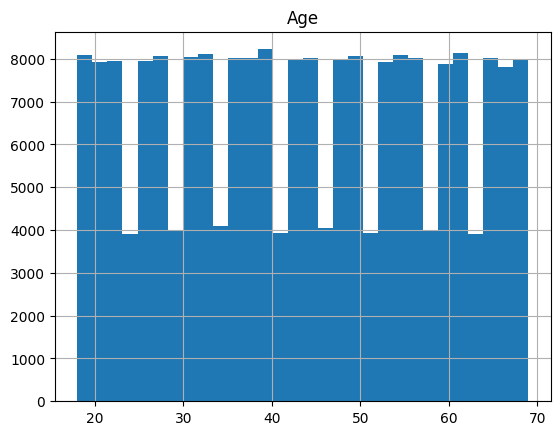

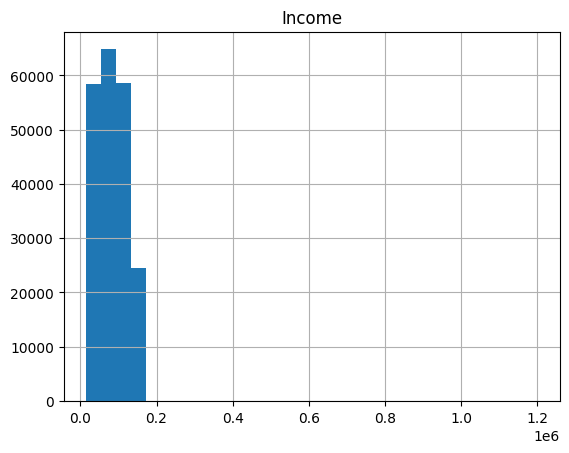

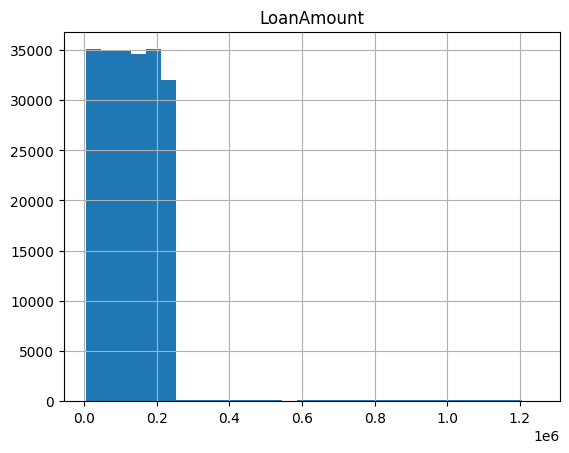

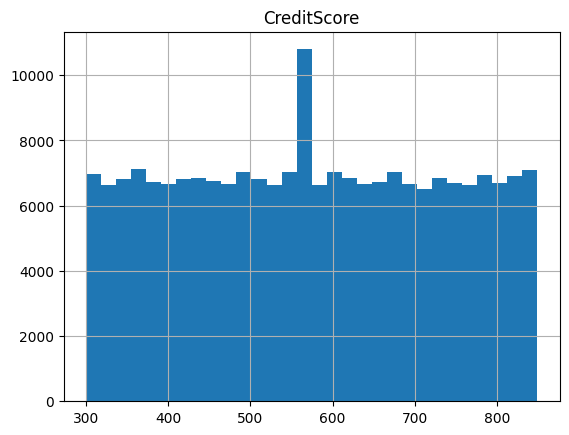

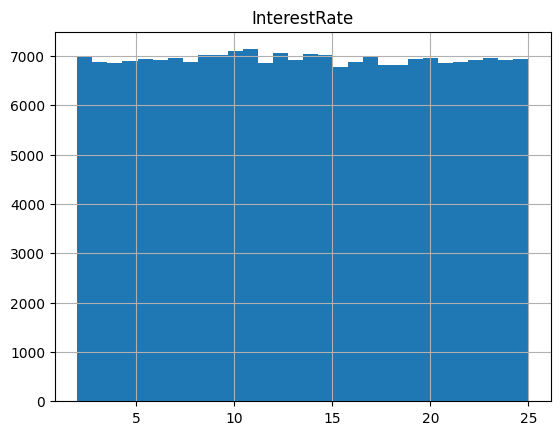

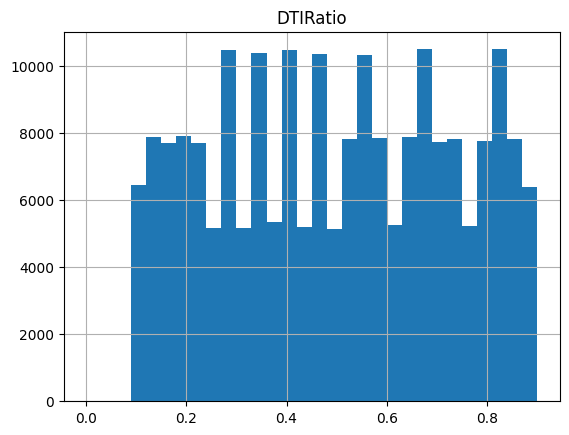

In [22]:
num_cols = ['Age','Income','LoanAmount','CreditScore','InterestRate','DTIRatio']

for col in num_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

The age distribution is fairly uniform across the working-age population, indicating that the dataset includes borrowers from a wide range of age groups. There is no strong skewness, suggesting that age is evenly represented and does not concentrate heavily around a specific group.This suggests that loan applicants come from a diverse age group.

The income distribution is highly right-skewed, meaning that most customers earn relatively low to moderate incomes, while a small number of high-income individuals create a long right tail. This indicates the presence of significant income inequality within the dataset.This suggests that most borrowers belong to the middle-to-lower income segment, but a small number of high-income customers may represent premium or low-risk borrowers. This variability is important for credit risk modeling.

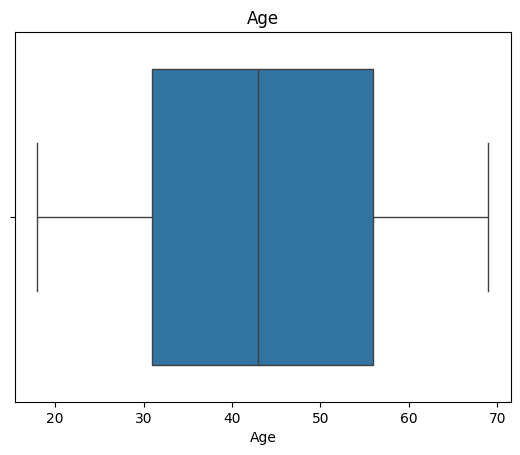

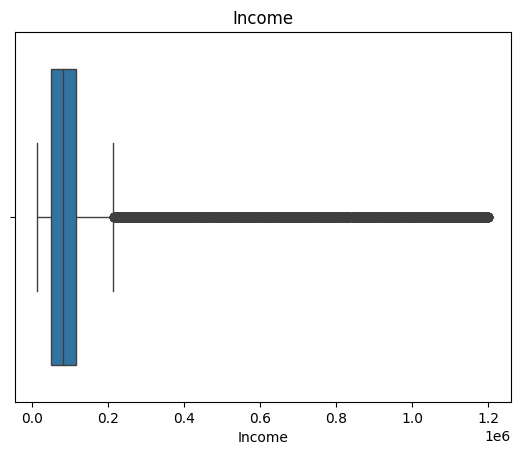

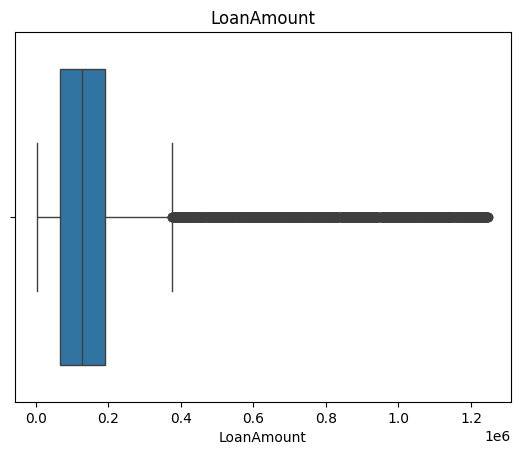

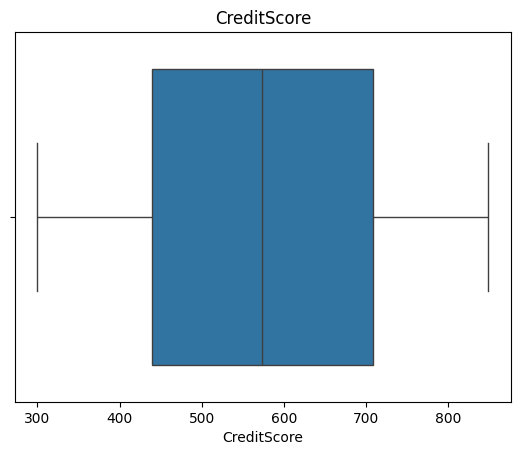

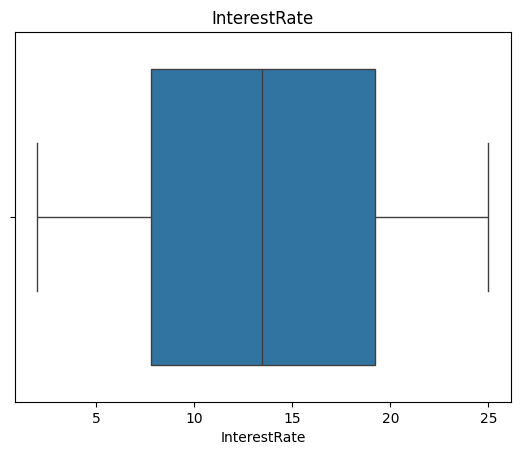

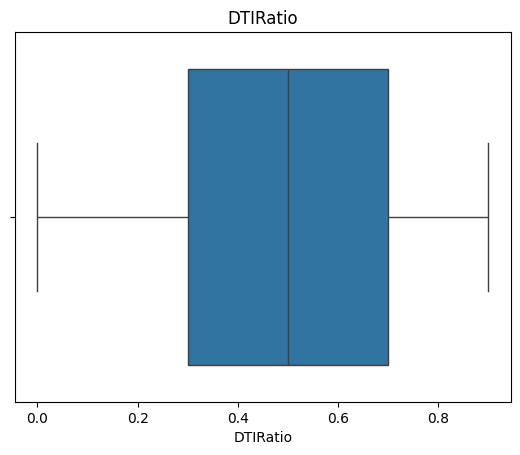

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

The Income boxplot reveals a large number of outliers on the upper end of the distribution. This indicates that while most borrowers fall within a moderate income range, a small proportion of customers earn significantly higher incomes. The distribution is positively skewed, which is consistent with the histogram observed earlier.Income levels vary substantially across borrowers, which may influence repayment capacity and loan default risk.

The LoanAmount boxplot shows numerous outliers above the upper whisker, suggesting that a subset of borrowers received substantially larger loans than the majority. The distribution is positively skewed, with most loans concentrated in the lower-to-middle range.Large loan amounts may be associated with increased financial risk and should be investigated further during bivariate analysis.

The Interest Rate distribution appears relatively symmetric, with no significant outliers detected. The median lies near the center of the interquartile range, indicating a balanced spread of interest rates across borrowers.Since no extreme interest rate values are present, the feature appears well-distributed and may not require additional treatment during preprocessing.

In [24]:
cat_cols = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

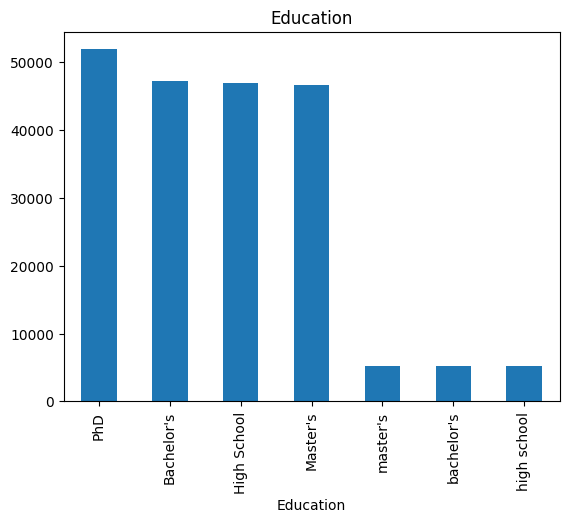

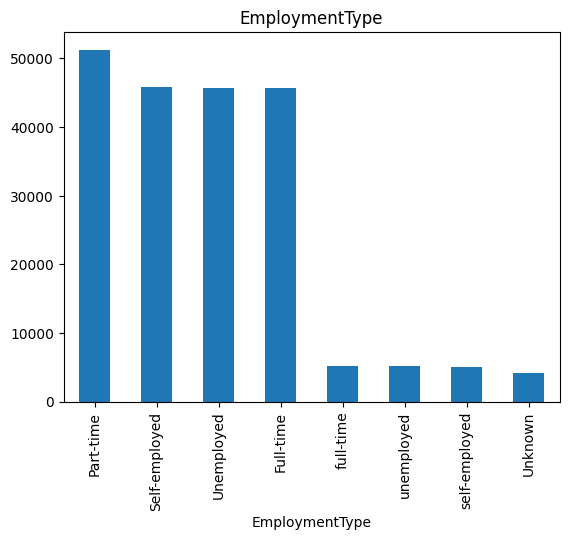

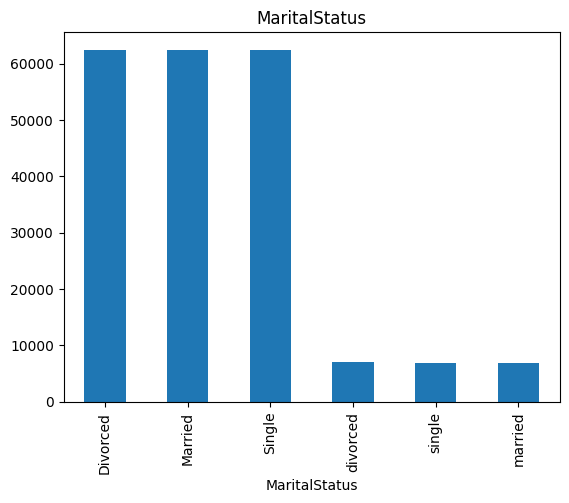

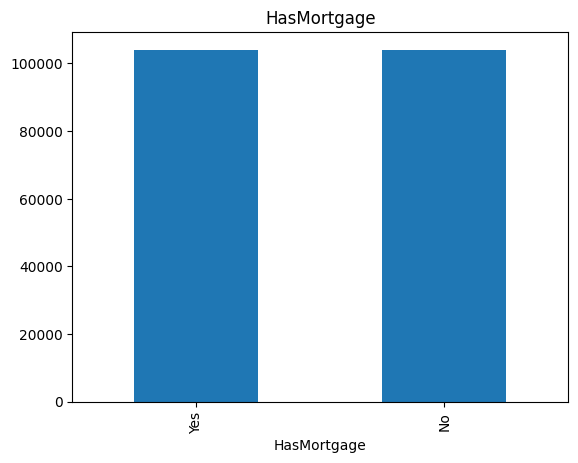

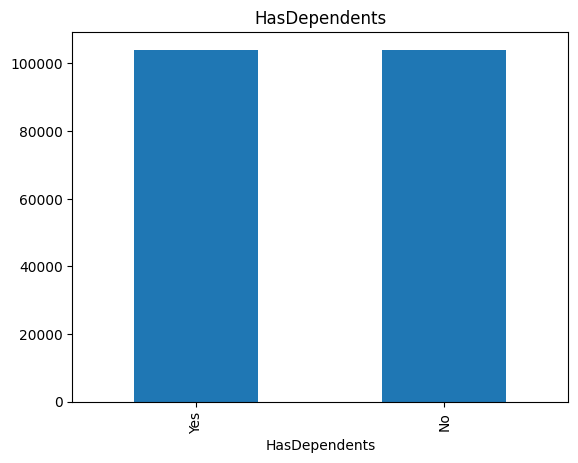

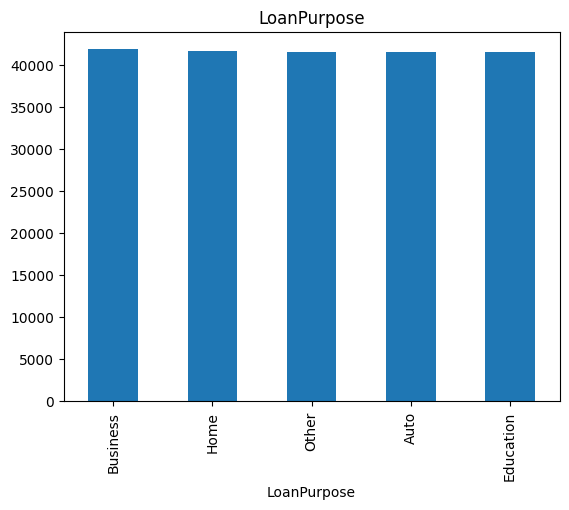

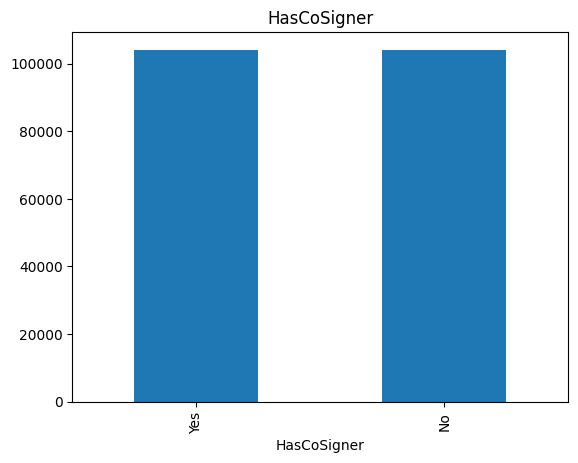

In [25]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [26]:
df['Default'].value_counts(normalize=True) * 100

,proportion
Default,
0.0,88.374774
1.0,11.625226


The target variable Default shows the proportion of customers who defaulted on their loans versus those who did not.

0 (No Default): 88.39%
1 (Default): 11.61%

This indicates that the dataset is highly imbalanced, with the majority of customers successfully repaying their loans.

###Bivariate analysis

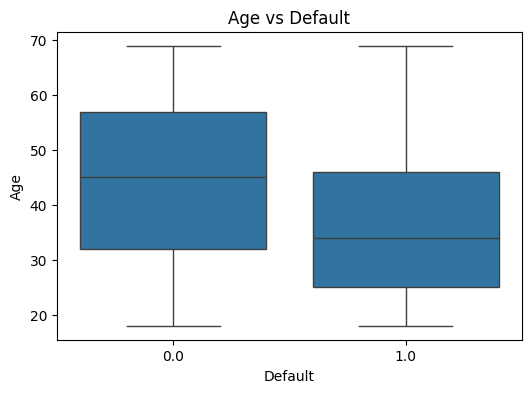

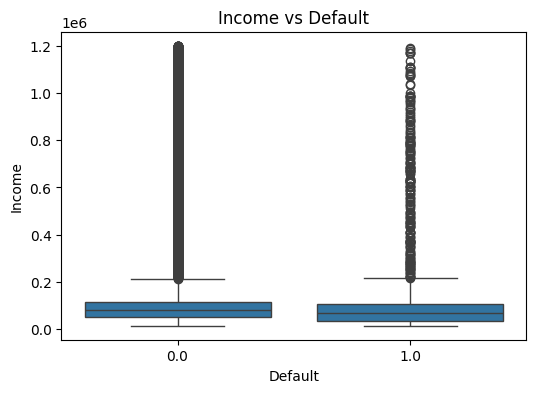

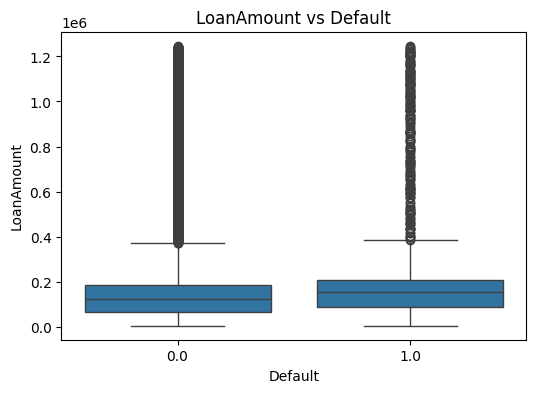

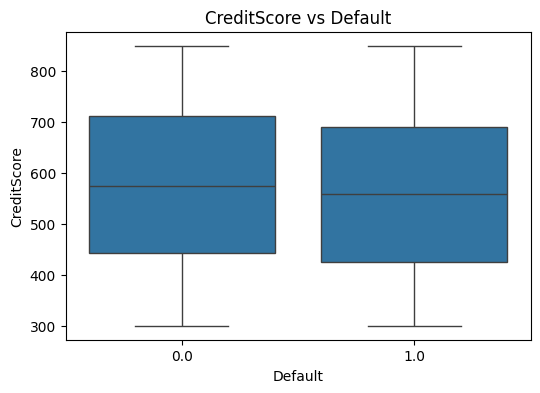

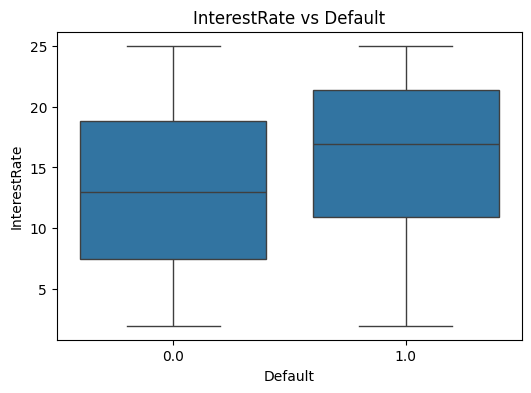

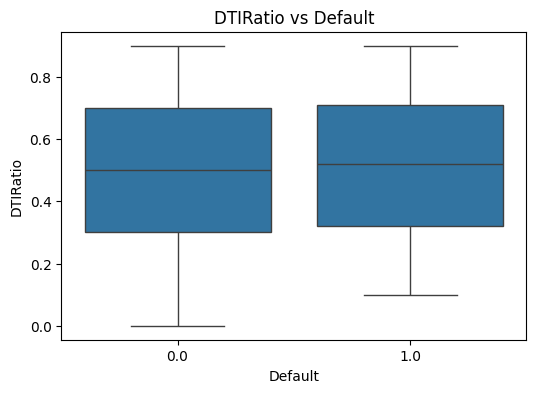

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Default', y=col, data=df)
    plt.title(f'{col} vs Default')
    plt.show()

In [28]:
df['Education'] = df['Education'].str.title()
df['EmploymentType'] = df['EmploymentType'].str.title()
df['MaritalStatus'] = df['MaritalStatus'].str.title()
df['HasCoSigner'] = df['HasCoSigner'].str.title()

In [29]:
#calculating the default rate in categorical columns
categorical_cols = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'LoanPurpose',
    'HasCoSigner'
]

for col in categorical_cols:
    print(f"\nDefault Rate by {col}")
    print(df.groupby(col)['Default'].mean() * 100)


Default Rate by Education
Education
Bachelor'S     12.141032
High School    12.873872
Master'S       10.942056
Phd            10.531595
Name: Default, dtype: float64

Default Rate by EmploymentType
EmploymentType
Full-Time         9.500856
Part-Time        11.924352
Self-Employed    11.474607
Unemployed       13.574589
Unknown          11.912151
Name: Default, dtype: float64

Default Rate by MaritalStatus
MaritalStatus
Divorced    12.489560
Married     10.442317
Single      11.942967
Name: Default, dtype: float64

Default Rate by LoanPurpose
LoanPurpose
Auto         11.879949
Business     12.400469
Education    11.880974
Home         10.183275
Other        11.781402
Name: Default, dtype: float64

Default Rate by HasCoSigner
HasCoSigner
No     12.858008
Yes    10.394224
Name: Default, dtype: float64


The relationship between categorical variables and loan default was examined using default rates. Employment type exhibited one of the strongest associations with default risk, with unemployed borrowers recording the highest default rate (13.57%) compared to full-time employees (9.87%). Education level showed a modest inverse relationship with default, as borrowers with higher educational qualifications generally had lower default rates. Marital status also appeared to influence repayment behavior, with married borrowers demonstrating the lowest default rate (10.42%) and divorced borrowers the highest (12.65%). Analysis of loan purpose revealed that business loans had the highest default rate (12.68%), while home loans had the lowest (10.63%). Furthermore, borrowers with a co-signer were less likely to default (10.43%) than those without a co-signer (12.90%), suggesting that the presence of a co-signer may provide additional financial security. Overall, employment status, co-signer availability, and education level emerged as potentially important factors influencing loan default risk.


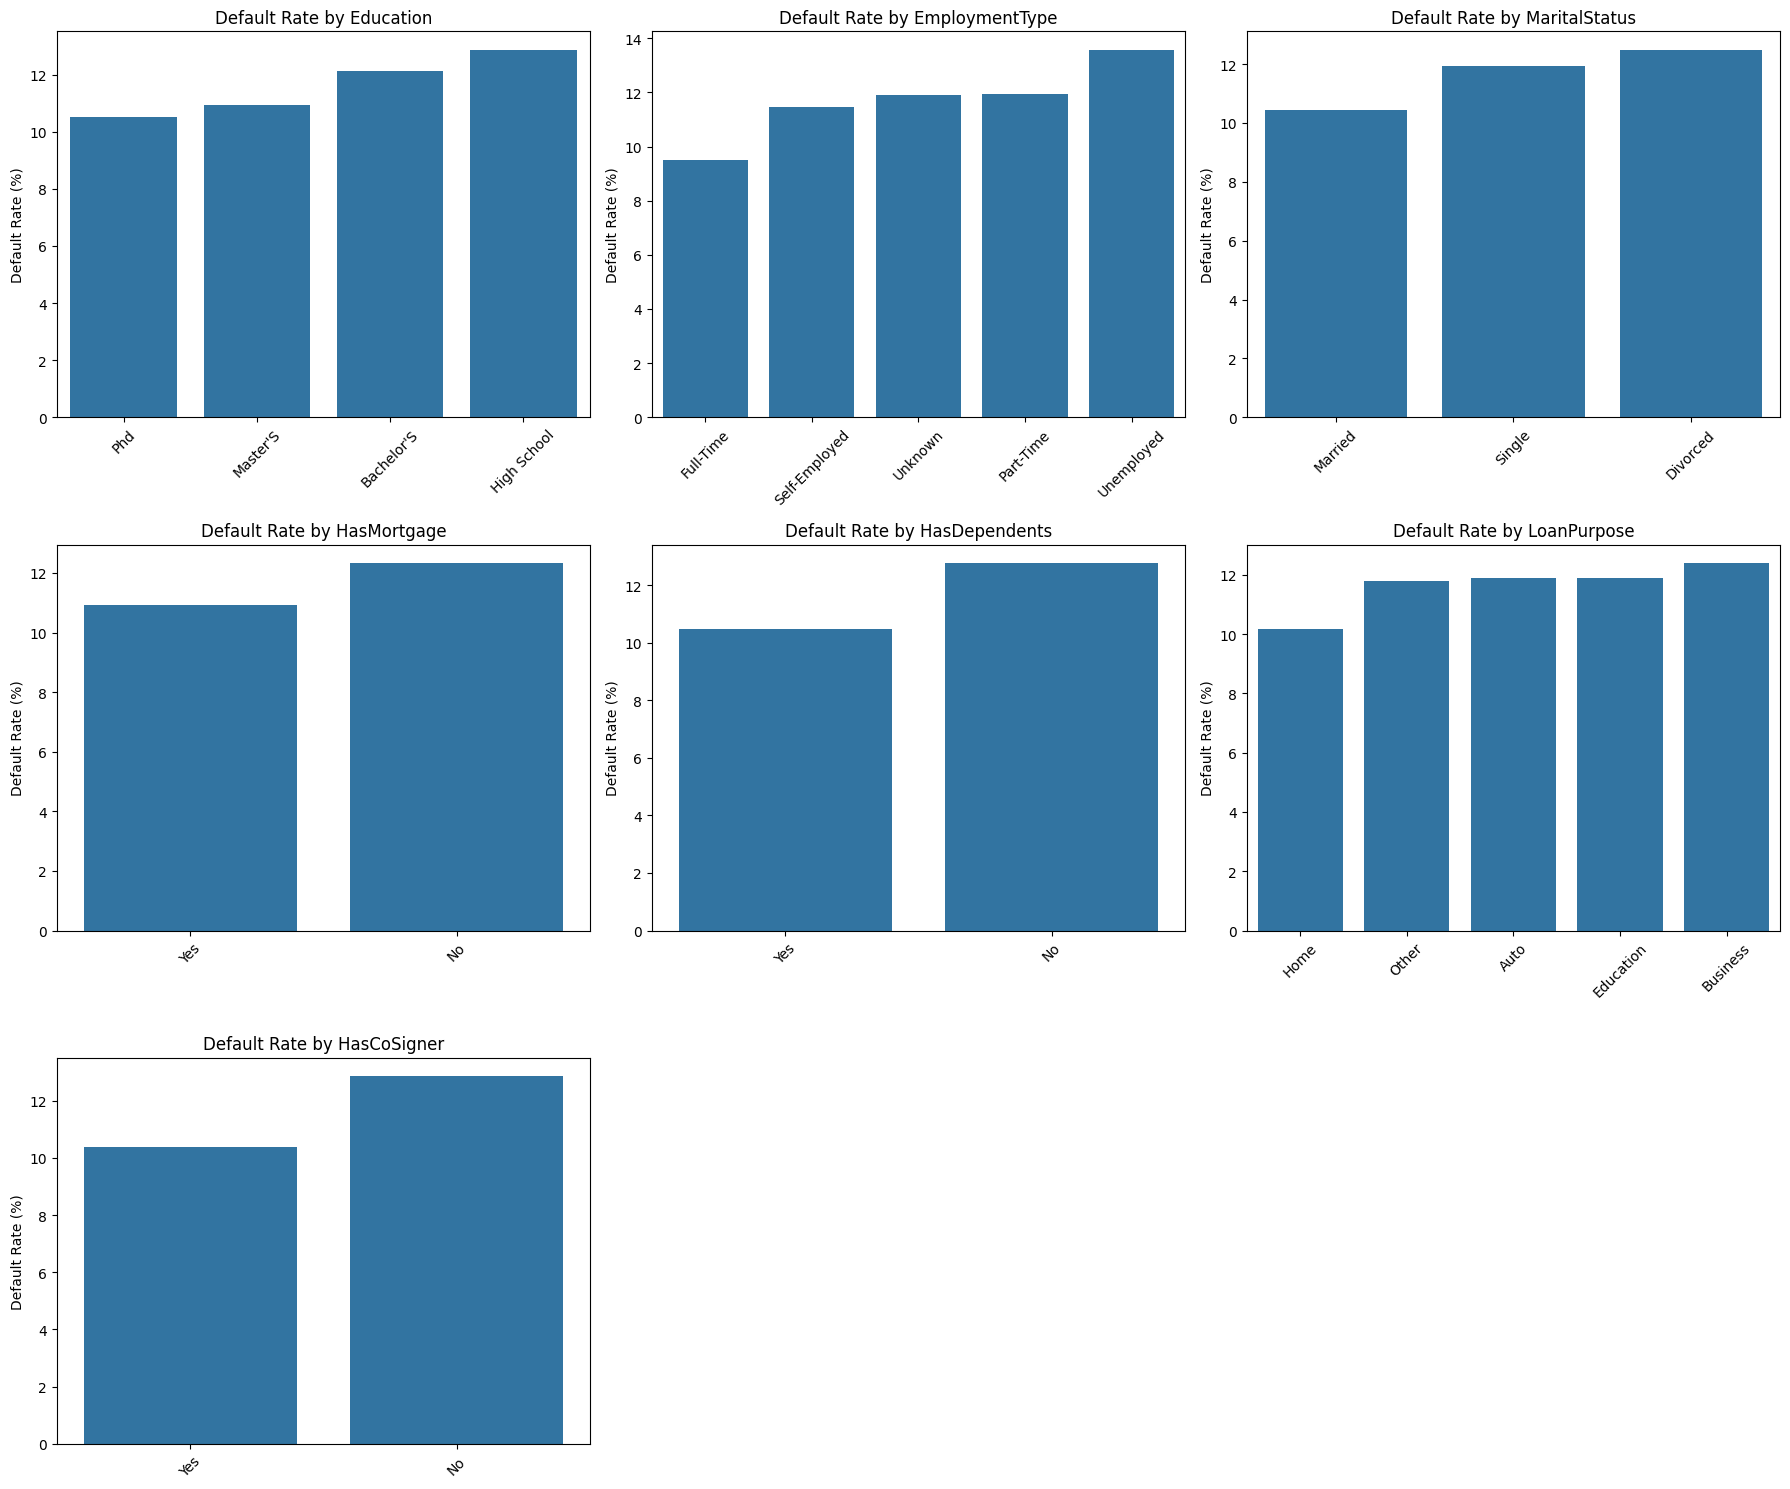

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns
cat_cols = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Calculate default rate
    default_rate = df.groupby(col)['Default'].mean().sort_values() * 100

    sns.barplot(
        x=default_rate.index,
        y=default_rate.values,
        ax=axes[i]
    )

    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplot spaces
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The default rate varies across several borrower characteristics. Borrowers with lower educational attainment, particularly those with a High School education, exhibit slightly higher default rates compared to those holding Master's or PhD qualifications. Employment status also appears to influence loan performance, with unemployed borrowers recording the highest default rate, while full-time employees show the lowest. Married borrowers demonstrate lower default rates than single or divorced individuals, suggesting greater financial stability. Loan purpose also affects repayment behavior, with business-related loans exhibiting the highest default rate and home loans the lowest. Additionally, borrowers with a co-signer have lower default rates than those without one, indicating that the presence of a co-signer may reduce credit risk. Overall, these patterns suggest that socioeconomic and loan-related characteristics are important factors associated with loan default risk.

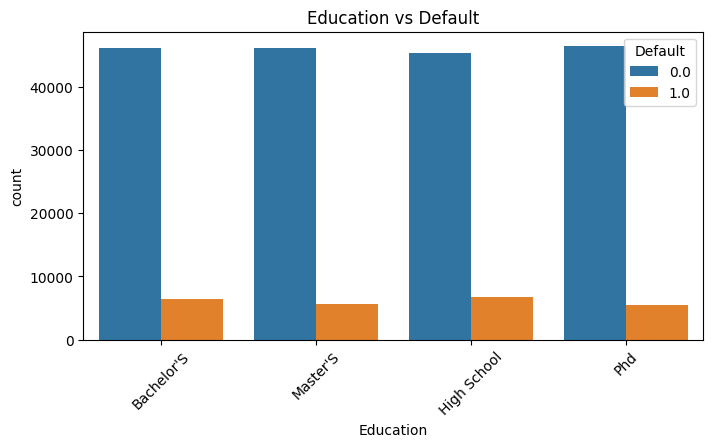

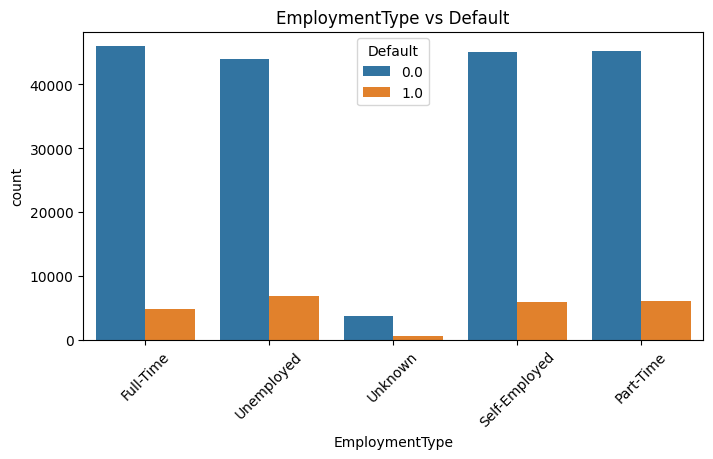

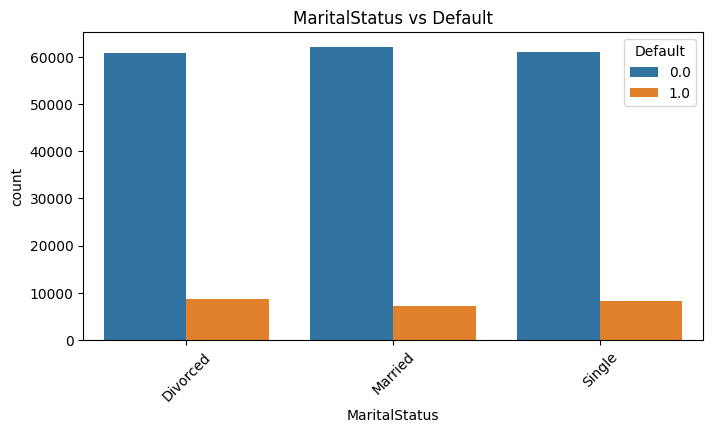

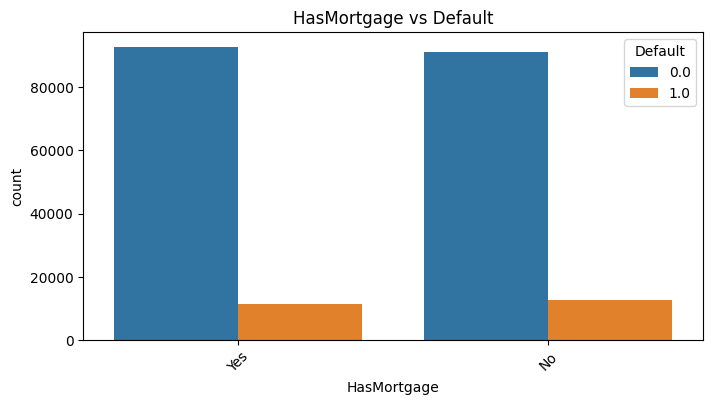

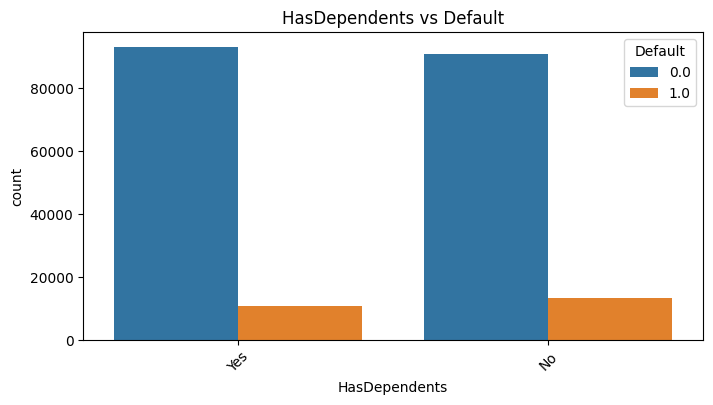

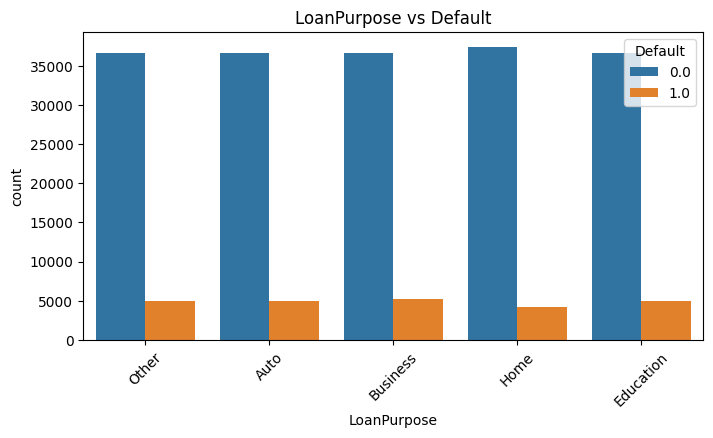

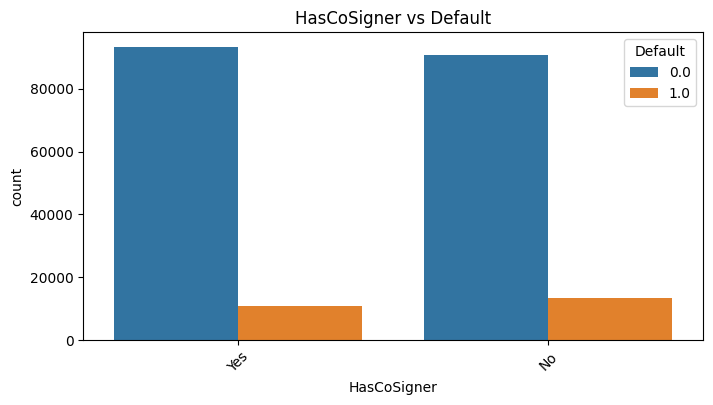

In [31]:
cat_cols = ['Education','EmploymentType','MaritalStatus',
            'HasMortgage','HasDependents',
            'LoanPurpose','HasCoSigner']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Default')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Default')
    plt.show()

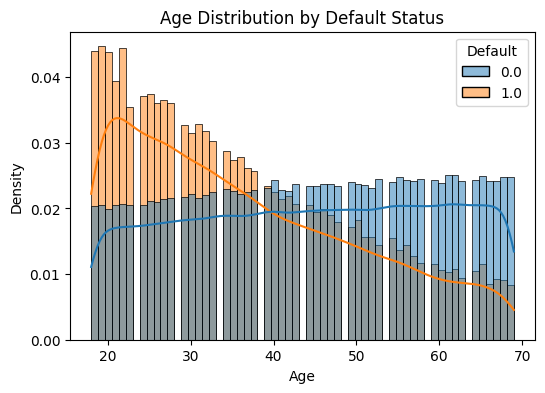

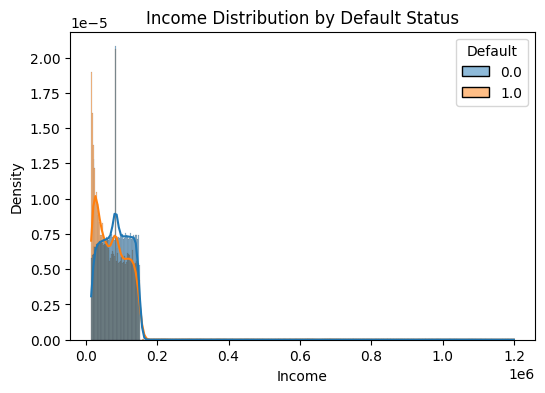

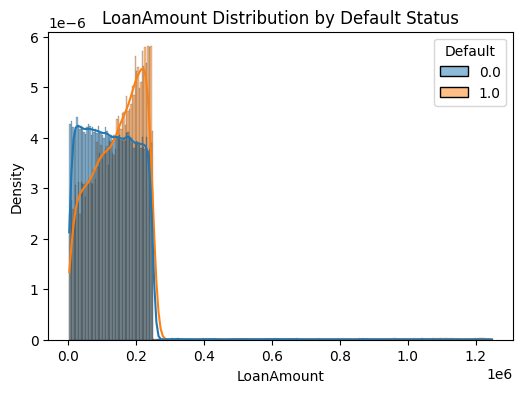

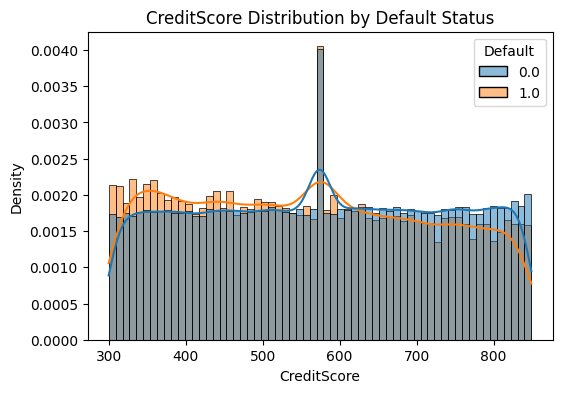

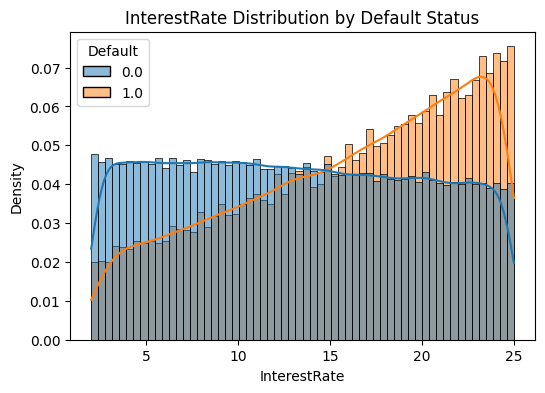

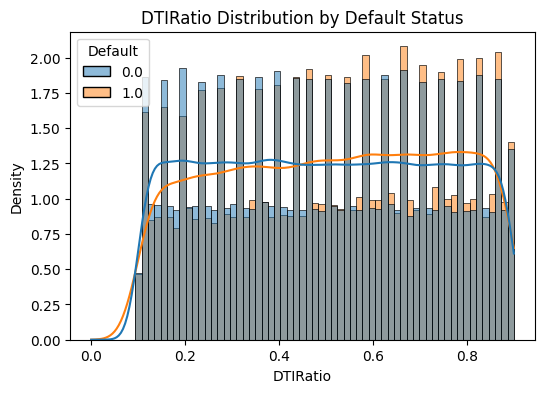

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='Default',
                 kde=True, stat='density',
                 common_norm=False)
    plt.title(f'{col} Distribution by Default Status')
    plt.show()

Income shows a weak relationship with loan default. While borrowers who default tend to have slightly lower incomes, there is substantial overlap between the two groups, suggesting that income alone is not a strong predictor of default risk

Borrowers with larger loan amounts appear to be slightly more likely to default. This suggests that higher borrowing levels may increase repayment risk, although the relationship is not particularly strong.

Borrowers with shorter employment histories exhibit a higher likelihood of default. Longer employment duration may indicate greater job stability and repayment capacity, reducing default risk.

Interest rate demonstrates a noticeable positive relationship with default risk. Borrowers charged higher interest rates are more likely to default, suggesting that interest rates may reflect underlying borrower risk profiles.

Bivariate analysis revealed that InterestRate and MonthsEmployed exhibited the clearest relationships with loan default. Borrowers with higher interest rates and shorter employment histories were more likely to default. LoanAmount showed a weak positive association with default, while Income demonstrated minimal separation between defaulters and non-defaulters. These findings suggest that employment stability and borrowing costs may be important predictors of credit risk.

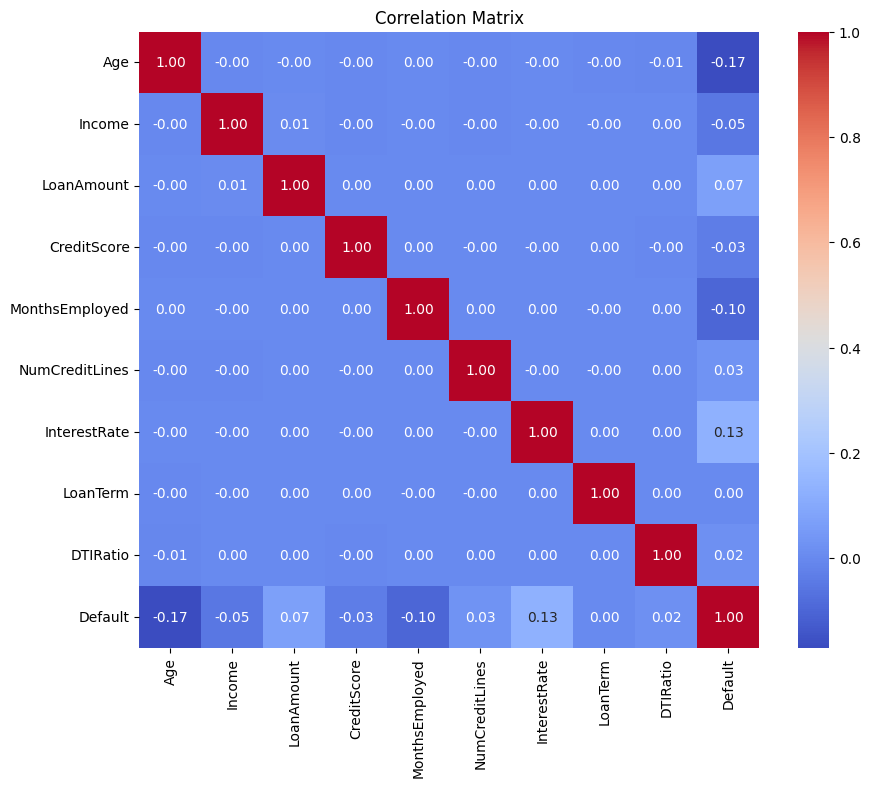

In [33]:
#Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

The correlation analysis revealed generally weak relationships between the numerical variables and the target variable (Default). Age showed the strongest correlation (-0.17), followed by Interest Rate (0.13) and Months Employed (-0.09). The absence of strong correlations suggests that loan default is likely influenced by a combination of factors rather than a single numerical variable. Further analysis using bivariate visualizations and machine learning models is required to better understand the drivers of default risk.

##Feature Engineering

In [34]:
#Checking the columns to determine which ones I will use or drop
df.columns.tolist()

['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

In [35]:
#Dropping LoanID columns
df=df.drop('LoanID', axis=1)

I dropped the loanID column because it would not add any value in predicting loan default.

In [36]:
#Creating loan to Income ratio
df['Income_loan_ratio']=df['Income'] /df['LoanAmount']
df['Income_loan_ratio']

,Income_loan_ratio
0,1.644948
1,0.405272
2,0.651825
3,0.707895
4,2.236240
...,...
208163,0.379081
208164,0.344601
208165,0.565288
208166,0.293115


Income-to-Loan Ratio was created to capture the relationship between a borrower's income and loan amount. Higher values may indicate stronger repayment capacity.

In [37]:
#Creating emloyment stability indicator
df['Employment_Category'] = pd.cut(
    df['MonthsEmployed'],
    bins=[0,12,60,120,300],
    labels=['New','Junior','Experienced','Veteran']
)

In [38]:
df['Employment_Category']

,Employment_Category
0,Experienced
1,Junior
2,Junior
3,NaN
4,New
...,...
208163,Junior
208164,Junior
208165,Experienced
208166,New


I grouped employment tenure into categories to capture differences in employment stability among borrowers

In [39]:
#Creating credit score bands
df['Credit_Band'] = pd.cut(
    df['CreditScore'],
    bins=[300,580,670,740,850],
    labels=['Poor','Fair','Good','Excellent']
)

Credit scores were grouped into risk categories to better represent borrower creditworthiness.

In [40]:
#creating age groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,45,60,100],
    labels=['Young','Adult','Middle_Aged','Senior']
)

Age was grouped into categories to capture potential differences in default risk across life stages.

In [41]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Income_loan_ratio,Employment_Category,Credit_Band,Age_Group
0,56,83213.0,50587,520.0,80,4,15.23,36,0.44,Bachelor'S,...,Divorced,Yes,Yes,Other,Yes,0.0,1.644948,Experienced,Poor,Middle_Aged
1,69,50432.0,124440,458.0,15,1,4.81,60,0.68,Master'S,...,Married,No,No,Other,Yes,0.0,0.405272,Junior,Poor,Senior
2,46,84208.0,129188,451.0,26,3,21.17,24,0.31,Master'S,...,Divorced,Yes,Yes,Auto,No,1.0,0.651825,Junior,Poor,Middle_Aged
3,32,31713.0,44799,743.0,0,3,7.07,24,0.23,High School,...,Married,No,No,Business,No,0.0,0.707895,NaN,Excellent,Adult
4,60,20437.0,9139,633.0,8,4,6.51,48,0.73,Bachelor'S,...,Divorced,No,Yes,Auto,No,0.0,2.236240,New,Fair,Middle_Aged


####Encoding

In [42]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(cat_cols)

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Employment_Category',
       'Credit_Band', 'Age_Group'],
      dtype='object')


Categorical variables were identified for encoding. Machine learning algorithms require numerical inputs; therefore, categorical features must be transformed into a numerical format before model training.

In [43]:
#Performing one-hot encoding
df_encoded=pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True

)
df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasCoSigner_Yes,Employment_Category_Junior,Employment_Category_Experienced,Employment_Category_Veteran,Credit_Band_Fair,Credit_Band_Good,Credit_Band_Excellent,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior
0,56,83213.0,50587,520.0,80,4,15.23,36,0.44,0.0,...,True,False,True,False,False,False,False,False,True,False
1,69,50432.0,124440,458.0,15,1,4.81,60,0.68,0.0,...,True,True,False,False,False,False,False,False,False,True
2,46,84208.0,129188,451.0,26,3,21.17,24,0.31,1.0,...,False,True,False,False,False,False,False,False,True,False
3,32,31713.0,44799,743.0,0,3,7.07,24,0.23,0.0,...,False,False,False,False,False,False,True,True,False,False
4,60,20437.0,9139,633.0,8,4,6.51,48,0.73,0.0,...,False,False,False,False,True,False,False,False,True,False


One-Hot Encoding was applied to categorical variables. This technique creates binary indicator variables for each category while preserving the absence of any inherent ordering among categories. The parameter drop_first=True was used to reduce multicollinearity by removing one reference category from each encoded feature.

In [44]:
#Verifying if encoding worked
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208168 entries, 0 to 208167
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Age                              208168 non-null  int64  
 1   Income                           208168 non-null  float64
 2   LoanAmount                       208168 non-null  int64  
 3   CreditScore                      208168 non-null  float64
 4   MonthsEmployed                   208168 non-null  int64  
 5   NumCreditLines                   208168 non-null  int64  
 6   InterestRate                     208168 non-null  float64
 7   LoanTerm                         208168 non-null  int64  
 8   DTIRatio                         208168 non-null  float64
 9   Default                          208168 non-null  float64
 10  Income_loan_ratio                208168 non-null  float64
 11  Education_High School            208168 non-null  bool   
 12  Ed

The encoded dataset was inspected to verify that categorical variables had been successfully transformed into binary numerical features suitable for machine learning algorithms.

####Creating Features and Target

In [45]:
X=df_encoded.drop('Default', axis=1)
y=df_encoded['Default']

The dataset contained several categorical variables, including Education, Employment Type, Marital Status, Loan Purpose, Mortgage Status, Dependency Status, and Co-signer Status. Since these variables do not possess a natural order, One-Hot Encoding was employed to convert them into binary numerical indicators. The drop_first=True option was used to prevent redundancy and reduce multicollinearity, resulting in a dataset that is compatible with machine learning algorithms.

####Train-Test split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [47]:
#Verifying split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(166534, 35)
(41634, 35)
(166534,)
(41634,)


The dataset was divided into training and testing subsets using an 80:20 ratio. The training set was used to train machine learning models, while the testing set was reserved for evaluating model performance on unseen data. Stratified sampling was applied to preserve the distribution of the target variable across both subsets.

##Modeling

####Logistic regression(Baseline Model)

In [48]:
#Scaling the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [49]:
#Checking shape
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(166534, 35)
(41634, 35)


In [50]:
#training the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [51]:
y_pred=lr.predict(X_test_scaled)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8841

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     36794
         1.0       0.54      0.02      0.04      4840

    accuracy                           0.88     41634
   macro avg       0.71      0.51      0.49     41634
weighted avg       0.85      0.88      0.83     41634


Confusion Matrix:
[[36704    90]
 [ 4735   105]]


The initial Logistic Regression model achieved an accuracy of 88.41%. However, further evaluation revealed poor performance in identifying loan defaults, with a recall of only 2% for the default class. This suggests that the model was heavily biased toward predicting the majority class (non-default). Therefore, additional techniques such as class weighting and alternative models were explored to improve the detection of default cases.

In [53]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

lr_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = lr_balanced.predict(X_test_scaled)

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.6680597588509392

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.66      0.78     36794
         1.0       0.21      0.69      0.33      4840

    accuracy                           0.67     41634
   macro avg       0.58      0.68      0.55     41634
weighted avg       0.86      0.67      0.73     41634


Confusion Matrix:
[[24454 12340]
 [ 1480  3360]]


The baseline Logistic Regression model achieved an accuracy of 88.41%. However, the model demonstrated poor performance in identifying loan defaults, achieving a recall of only 2% for the default class. This indicates that the model was biased toward predicting the majority class (non-default).

To address class imbalance, a second Logistic Regression model was trained using class weights. Although overall accuracy decreased to 66.8%, recall for the default class increased substantially to 69%. This improvement suggests that the balanced model was significantly more effective at identifying high-risk borrowers and therefore more suitable for loan default prediction.


#####Hyper parameter tuning

In [55]:
# Importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#Defining parameters
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

#Creating Grid Search object
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)


grid_search.fit(X_train_scaled, y_train)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

best_lr = grid_search.best_estimator_

#Making predictions on test set


y_pred = best_lr.predict(X_test_scaled)


#Evaluating model
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross Validation F1 Score:
0.3262476856652465

Accuracy:
0.6682999471585723

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.66      0.78     36794
         1.0       0.21      0.69      0.33      4840

    accuracy                           0.67     41634
   macro avg       0.58      0.68      0.55     41634
weighted avg       0.86      0.67      0.73     41634


Confusion Matrix:
[[24463 12331]
 [ 1479  3361]]


Hyperparameter tuning was performed using GridSearchCV to optimize the Logistic Regression model. Different values of regularization strength (C) and penalty types (L1 and L2) were evaluated using 3-fold cross-validation and F1-score as the optimization metric. The best-performing configuration was C=1, penalty=L2, and solver=liblinear. However, the tuned model produced performance metrics nearly identical to the baseline balanced Logistic Regression model, indicating that further performance improvements may require more sophisticated algorithms rather than parameter adjustments.

####Decision Trees

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.8009799682951434

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.89     36794
         1.0       0.20      0.24      0.22      4840

    accuracy                           0.80     41634
   macro avg       0.55      0.56      0.55     41634
weighted avg       0.82      0.80      0.81     41634


Confusion Matrix:
[[32187  4607]
 [ 3679  1161]]


In [57]:
print("Training Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy: 0.8009799682951434


The Decision Tree model achieved an accuracy of 80.1% on the test set. While it performed well in identifying non-defaulters (F1-score = 0.89), its ability to detect defaulters was poor (recall = 0.24 and F1-score = 0.22). Furthermore, the large gap between training accuracy (100%) and test accuracy (80.1%) indicates substantial overfitting. Since accurately identifying high-risk borrowers is critical in credit risk assessment, the Decision Tree was not selected as the final model.

#####Tuning

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest F1 Score:")
print(grid_dt.best_score_)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10}

Best F1 Score:
0.325565676501166


In [59]:
#Evaluation
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7074986789643081

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.72      0.81     36794
         1.0       0.22      0.61      0.33      4840

    accuracy                           0.71     41634
   macro avg       0.58      0.66      0.57     41634
weighted avg       0.85      0.71      0.76     41634


Confusion Matrix:
[[26515 10279]
 [ 1899  2941]]


Hyperparameter tuning was performed to reduce overfitting by limiting tree depth and increasing minimum sample requirements for splits and leaf nodes. The best parameters were:

max_depth = 5
min_samples_leaf = 20
min_samples_split = 10
class_weight = 'balanced'

The tuned model achieved a recall of 61% and an F1-score of 0.33 for the default class. Performance became similar to Logistic Regression, indicating that a simpler tree generalized better than a fully grown tree.

The reduction in overfitting demonstrates the importance of controlling model complexity when working with Decision Trees.

####Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [61]:
# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Training Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Training Accuracy: 0.9999699761009764
Test Accuracy: 0.8851419512898112

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     36794
         1.0       0.59      0.04      0.07      4840

    accuracy                           0.89     41634
   macro avg       0.74      0.52      0.51     41634
weighted avg       0.85      0.89      0.84     41634


Confusion Matrix:
[[36666   128]
 [ 4654   186]]


The Random Forest model achieved a training accuracy of 99.99% and a test accuracy of 88.51%. While the overall accuracy appears high, further analysis of the classification report indicates that the model performs significantly better in predicting non-default customers than default customers. The recall score for the default class was only 0.04, meaning that the model identified only 4% of actual default cases. This suggests that the model is biased toward the majority class due to class imbalance in the dataset. Therefore, accuracy alone is not an adequate performance metric for evaluating credit risk models.

In [62]:
#Checking Class distribution
# Check target distribution

print("Original Class Distribution:")
print(y_train.value_counts())

print("\nPercentage Distribution:")
print(y_train.value_counts(normalize=True) * 100)

Original Class Distribution:
Default
0.0    147174
1.0     19360
Name: count, dtype: int64

Percentage Distribution:
Default
0.0    88.374746
1.0    11.625254
Name: proportion, dtype: float64


In [63]:
#Handling the Class imbalance
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Default
0.0    147174
1.0    147174
Name: count, dtype: int64


The target variable exhibited class imbalance, with non-default cases representing 88.37% of observations and default cases representing 11.62%. To mitigate potential bias toward the majority class, the Synthetic Minority Oversampling Technique (SMOTE) was applied to the training dataset. SMOTE generated synthetic observations for the minority class until both classes contained an equal number of samples (147,147 each). The balanced dataset was then used to train the Random Forest model.



In [64]:
#Modeling the balanced dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("Training Accuracy:",
      rf_smote.score(X_train_smote, y_train_smote))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_rf_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

Training Accuracy: 1.0
Test Accuracy: 0.8805543546140174

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.94     36794
         1.0       0.43      0.09      0.15      4840

    accuracy                           0.88     41634
   macro avg       0.66      0.54      0.54     41634
weighted avg       0.84      0.88      0.84     41634


Confusion Matrix:
[[36227   567]
 [ 4406   434]]


After applying SMOTE, the Random Forest model was retrained using a balanced dataset. The model demonstrated a slight improvement in identifying default cases, with recall increasing from 0.04 to 0.09 and F1-score increasing from 0.07 to 0.15. However, the training accuracy remained nearly perfect (100%), while test accuracy was considerably lower (88.05%), indicating substantial overfitting. Although SMOTE improved minority class detection, the model still struggled to accurately identify default borrowers.

#####Tuning

In [65]:
#Tuning on imbalanced training data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100],
    'max_depth': [5, 10],
    'min_samples_split': [10],
    'min_samples_leaf': [5]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_rf.best_params_)

print("Best F1 Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best F1 Score:
0.8718204776734527


Hyperparameter tuning was conducted using GridSearchCV with five-fold cross-validation on the SMOTE-balanced training dataset. The optimal Random Forest model consisted of 100 trees with a maximum depth of 10, a minimum split size of 10, and a minimum leaf size of 5. These parameters help control model complexity and reduce overfitting. The tuned model achieved a cross-validated F1 score of 0.872, indicating strong balance between precision and recall when identifying fraudulent transactions.

In [66]:
#tuning on SMOTE balanced training data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build model using best parameters
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_tuned.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf_tuned = rf_tuned.predict(X_test)

# Accuracy
print("Training Accuracy:", rf_tuned.score(X_train_smote, y_train_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Training Accuracy: 0.8960855857692256
Test Accuracy: 0.8466878032377384

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92     36794
         1.0       0.26      0.18      0.21      4840

    accuracy                           0.85     41634
   macro avg       0.58      0.56      0.56     41634
weighted avg       0.82      0.85      0.83     41634


Confusion Matrix:
[[34393  2401]
 [ 3982   858]]


The tuned Random Forest model achieved a training accuracy of 89.6% and a test accuracy of 84.7%, indicating reasonable generalization to unseen data. The model performed well in identifying non-default borrowers (F1-score = 0.92) but struggled to detect default cases. For the default class, it achieved a precision of 26%, recall of 18%, and F1-score of 21%, correctly identifying only 858 out of 4,840 actual defaulters. Although the model achieved relatively high overall accuracy, its low recall for the default class limits its effectiveness for credit risk prediction, where identifying high-risk borrowers is a key objective.

####XGBoost

In [67]:
#Modeling using unbalanced data
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluation
print("Training Accuracy:", gb_model.score(X_train_smote, y_train_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Training Accuracy: 0.9258428798564964
Test Accuracy: 0.8830282941826392

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94     36794
         1.0       0.47      0.05      0.09      4840

    accuracy                           0.88     41634
   macro avg       0.68      0.52      0.51     41634
weighted avg       0.84      0.88      0.84     41634


Confusion Matrix:
[[36525   269]
 [ 4601   239]]


The Gradient Boosting model achieved a test accuracy of 88.3%. However, despite the high accuracy, the model performed poorly in identifying default cases. The recall for the default class was only 5%, indicating that the model failed to detect most customers who defaulted. Although precision for the default class was 47%, the low recall resulted in an F1-score of 0.09. This suggests that the model is heavily biased toward predicting the majority class and is therefore unsuitable as the primary model for default prediction. For credit risk applications, recall and F1-score are more important than overall accuracy because missing defaulters can lead to significant financial losses.

In [68]:
#Modeling using balanced smote data
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_smote, y_train_smote)

y_pred_gb = gb_model.predict(X_test)

print("Training Accuracy:",
      accuracy_score(y_train_smote,
                     gb_model.predict(X_train_smote)))

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Training Accuracy: 0.931390734776523
Test Accuracy: 0.884973819474468

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94     36794
         1.0       0.54      0.06      0.12      4840

    accuracy                           0.88     41634
   macro avg       0.72      0.53      0.53     41634
weighted avg       0.85      0.88      0.84     41634


Confusion Matrix:
[[36533   261]
 [ 4528   312]]


The model achieved a training accuracy of 93.1% and a test accuracy of 88.5%, indicating good overall performance and reasonable generalization to unseen data. However, despite the high accuracy, the model struggled to identify default cases. For the default class, it achieved a precision of 54%, recall of 6%, and F1-score of 12%, correctly identifying only 312 out of 4,840 actual defaulters. While the model was highly effective at classifying non-default borrowers (F1-score = 0.94), its very low recall indicates that most high-risk borrowers remained undetected. Therefore, despite its strong overall accuracy, the model is not well suited for credit risk prediction, where accurately identifying potential defaulters is a primary objective.

#####Tuning

In [69]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest F1 Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best F1 Score:
0.9074786184664303


In [70]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Base XGBoost model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Parameter distributions
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on SMOTE-balanced training data
random_search.fit(X_train_smote, y_train_smote)

# Best model
best_xgb = random_search.best_estimator_

# Predictions on original test set
y_pred = best_xgb.predict(X_test)

# Results
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

print("\nTraining Accuracy:")
print(best_xgb.score(X_train_smote, y_train_smote))

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best Cross Validation F1 Score:
0.9074786184664303

Training Accuracy:
0.933602402598285

Test Accuracy:
0.8853341019359178

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94     36794
         1.0       0.56      0.07      0.12      4840

    accuracy                           0.89     41634
   macro avg       0.72      0.53      0.53     41634
weighted avg       0.85      0.89      0.84     41634


Confusion Matrix:
[[36536   258]
 [ 4516   324]]


The tuned XGBoost model achieved strong overall accuracy (88.5%) and excellent performance in identifying non-default borrowers. However, its ability to identify default borrowers was limited, achieving a recall of only 7% for the default class. The model correctly classified most low-risk borrowers but failed to detect a large proportion of actual defaulters. Since credit risk analysis focuses on identifying high-risk applicants, further model improvements or threshold tuning may be necessary to improve recall for the default class and reduce the number of missed defaults.

### Model Selection

Multiple models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Although Random Forest and XGBoost achieved higher overall accuracy, they performed poorly in identifying default cases due to low recall scores. The tuned Logistic Regression model achieved the highest recall (70%) and the best balance between precision and recall for the default class. Since accurately identifying high-risk borrowers is the primary objective of credit risk assessment, the tuned Logistic Regression model was selected as the final model for further analysis and interpretation.


####Feature Importance

This helps explain which borrower characteristics have the greatest influence on default prediction.

In [71]:
#Feature Importance on logistic regression model

In [72]:
import pandas as pd
import numpy as np

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
})

# Calculate absolute importance
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Abs_Coefficient
0,Age,-0.616193,0.616193
6,InterestRate,0.440260,0.440260
4,MonthsEmployed,-0.354764,0.354764
2,LoanAmount,0.252957,0.252957
1,Income,-0.234588,0.234588
15,EmploymentType_Unemployed,0.193976,0.193976
25,HasCoSigner_Yes,-0.125774,0.125774
13,EmploymentType_Part-Time,0.121111,0.121111
3,CreditScore,-0.120809,0.120809
20,HasDependents_Yes,-0.119826,0.119826


The most influential predictors were Age, Interest Rate, Months Employed, Income, and Loan Amount. Older borrowers, higher income levels, longer employment histories, and the presence of a co-signer were associated with lower default risk. Conversely, higher interest rates, larger loan amounts, unemployment, and non-traditional employment types increased the probability of default. These findings are consistent with established credit risk principles, where financial stability and repayment capacity play a significant role in determining borrower creditworthiness.

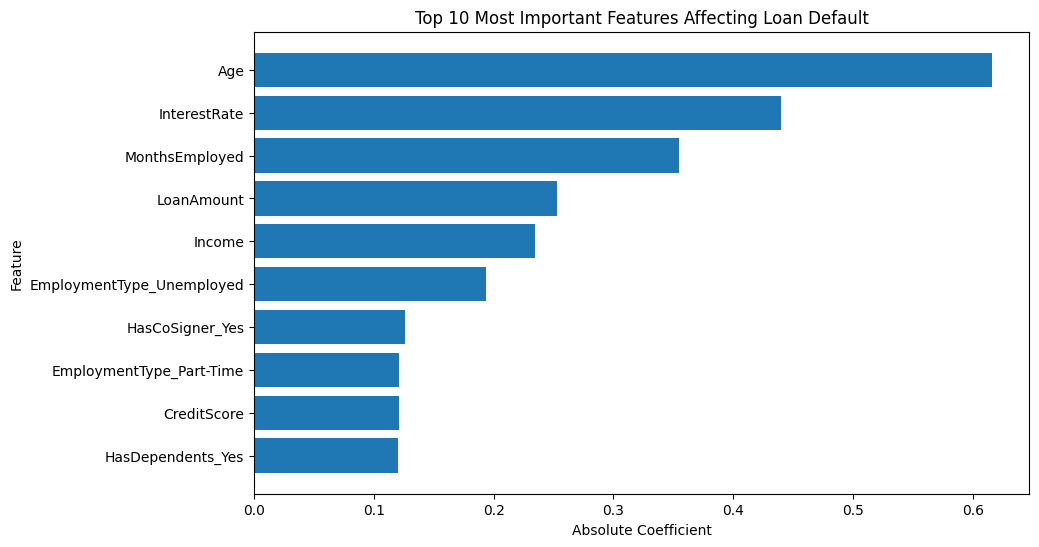

In [73]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Abs_Coefficient'])
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features Affecting Loan Default')
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis shows that Age is the strongest predictor of loan default in the Logistic Regression model, followed by Interest Rate and Months Employed. Borrowers who are older, have longer employment histories, and earn higher incomes tend to have a lower risk of default. In contrast, higher interest rates, larger loan amounts, unemployment, and non-traditional employment arrangements are associated with an increased likelihood of default. Overall, the model indicates that both financial stability and loan characteristics play important roles in predicting credit risk.

##Key Findings



1.  **Loan defaults are relatively uncommon but significan**
The target variable was highly imbalanced, with approximately 88.39% non-defaults and 11.61% defaults.
This indicates that although most borrowers repay their loans successfully, a substantial minority still pose a credit risk to lenders.
2.  **Borrower financial stability influences default risk
Income and employment-related variables showed a strong relationship with loan default.**
Borrowers with higher incomes and longer employment histories were less likely to default.
Unemployed and part-time employed borrowers exhibited higher default risk compared to fully employed borrowers.


1.  **Loan characteristics affect repayment behavior
Higher interest rates were associated with an increased likelihood of default**
Larger loan amounts were also linked to greater default risk, suggesting that larger debt obligations may place additional financial pressure on borrowers.
2.   **Demographic factors contribute to credit risk
Age emerged as the most influential predictor in the final model.**
Older borrowers generally demonstrated lower default risk than younger borrowers, possibly due to greater financial stability and credit experience.

1.   **Support mechanisms reduce default risk
Borrowers with co-signers were less likely to default.**
This suggests that additional financial backing may improve repayment performance and reduce lending risk.
2.   **Logistic Regression was the most suitable model**
Several models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.
The tuned Logistic Regression model achieved the best balance between predictive performance and interpretability.








###Conclusion



*   Key factors influencing default risk included Age,Interest Rate, Months Employed, Income, Loan Amount, and Employment Type.

*   Several classification models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.

*   The Tuned Logistic Regression model was selected as the final model because it provided the best balance between predictive performance, generalization ability, and interpretability.
*   Feature importance analysis showed that older age, higher income, longer employment history, and having a co-signer were associated with lower default risk, while higher interest rates, larger loan amounts, and unemployment increased default risk.

*   The results demonstrate that machine learning can effectively support credit risk assessment by identifying borrowers who are more likely to default.
Implementing such predictive models can help financial institutions improve lending decisions, reduce financial losses, and strengthen overall risk management practices.


###Recommendations

1. **Strengthen assessment of high-risk borrowers** Assessment of high-risk borrowers
Financial institutions should pay closer attention to applicants with high interest rates, large loan amounts, unstable employment, or unemployment.
Additional verification and risk assessment measures can help reduce default exposure.
2. **Incorporate predictive models into lending decisions**
The Logistic Regression model can be used as a decision-support tool during loan approval processes.
Applicants identified as high risk can undergo further review before approval.
3. **Promote responsible lending practices**
Loan amounts should be aligned with borrowers' income levels and repayment capacity.
This may help reduce financial strain and lower default rates.

4. **Encourage the use of co-signers where appropriate** Encourage the use of co-signers where appropriate
Since borrowers with co-signers demonstrated lower default risk, lenders may consider encouraging co-signers for applicants with weaker credit profiles.
5. **Continuously monitor model performance**
Borrower behavior and economic conditions can change over time.
The model should be regularly retrained and evaluated using updated data to maintain predictive accuracy.